In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fim import apriori, fpgrowth

In [184]:
file_name= "..\\dm1_25_26_dataset\\cleaned_dataset.csv"
df = pd.read_csv(file_name)

In [185]:
df.columns

Index(['BGGId', 'Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'ComMinPlaytime', 'ComMaxPlaytime', 'IsReimplementation', 'Kickstarted', 'Score_strategygames', 'Score_abstracts', 'Score_familygames', 'Score_thematic', 'Score_cgs', 'Score_wargames', 'Score_partygames', 'Score_childrensgames', 'Rating', 'Avg_popularity_log', 'NumAlternates_log', 'NumImplementations_log', 'NumExpansions_log', 'NumWeightVotes_log'], dtype='object')

In [186]:
df.describe()

,BGGId,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,ComMinPlaytime,ComMaxPlaytime,IsReimplementation,Kickstarted,...,Score_cgs,Score_wargames,Score_partygames,Score_childrensgames,Rating,Avg_popularity_log,NumAlternates_log,NumImplementations_log,NumExpansions_log,NumWeightVotes_log
count,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,...,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000,19729.000000
mean,118477.403214,2007.425212,1.995102,1.996959,4.646561,7.623346,51.499138,63.924223,0.116782,0.161792,...,0.000318,0.000337,0.000324,0.000367,1.892291,5.157149,0.498689,0.179849,0.349613,2.630245
std,104111.249604,12.603682,0.759115,0.637271,2.181989,4.907054,46.933212,56.178342,0.321169,0.368269,...,0.009116,0.008537,0.008991,0.009120,0.734881,1.364527,0.713194,0.361079,0.717561,1.340329
min,1.000000,1950.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.098612,0.000000,0.000000,0.000000,0.693147
25%,12947.000000,2003.000000,1.333300,2.000000,4.000000,4.000000,20.000000,30.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,4.143135,0.000000,0.000000,0.000000,1.609438
50%,111069.000000,2012.000000,2.000000,2.000000,4.000000,8.000000,30.000000,45.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,4.905275,0.000000,0.000000,0.000000,2.397895
75%,206068.000000,2017.000000,2.500000,2.000000,6.000000,11.000000,60.000000,90.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,5.951510,0.693147,0.000000,0.693147,3.332205
max,349131.000000,2021.000000,5.000000,8.000000,16.000000,21.000000,250.000000,360.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,3.000000,10.982203,6.746412,3.663562,5.541264,8.945593


In [187]:
print(df.columns.tolist())

['BGGId', 'Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'ComMinPlaytime', 'ComMaxPlaytime', 'IsReimplementation', 'Kickstarted', 'Score_strategygames', 'Score_abstracts', 'Score_familygames', 'Score_thematic', 'Score_cgs', 'Score_wargames', 'Score_partygames', 'Score_childrensgames', 'Rating', 'Avg_popularity_log', 'NumAlternates_log', 'NumImplementations_log', 'NumExpansions_log', 'NumWeightVotes_log']


qcut usa i quantili vs cut non li usa, e i valori vanno specificati

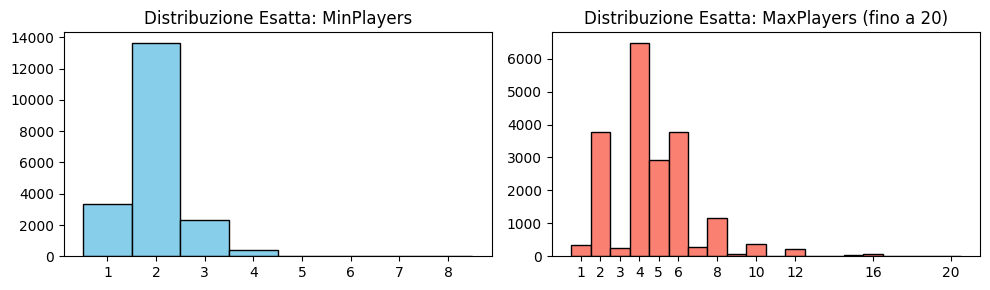

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Grafico MinPlayers (Esatto)
axes[0].hist(df['MinPlayers'], bins=range(1, 10), align='left', edgecolor='black', color='skyblue')
axes[0].set_title('Distribuzione Esatta: MinPlayers')
axes[0].set_xticks(range(1, 9))

# Grafico MaxPlayers (Esatto - limitato a 20 per chiarezza visiva)
axes[1].hist(df['MaxPlayers'], bins=range(1, 22), align='left', edgecolor='black', color='salmon')
axes[1].set_title('Distribuzione Esatta: MaxPlayers (fino a 20)')
axes[1].set_xticks([1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20])

plt.tight_layout()
plt.show()

In [189]:
bins= [0, 2, 4, 8, df['MaxPlayers'].max()]
labels= ['Solo/Duo', 'Small Group', 'Mid Group', 'Large/Party']
df["MaxPlayersBin"] = pd.cut(df['MaxPlayers'],bins=bins, labels=labels)
print(df['MaxPlayersBin'].value_counts())

MaxPlayersBin
Mid Group      8100
Small Group    6718
Solo/Duo       4126
Large/Party     785
Name: count, dtype: int64


In [190]:
bins= [0, 1, 2, df['MinPlayers'].max()]
labels= ['Solo Friendly', 'Duo', 'Group']
df["MinPlayersBin"] = pd.cut(df['MinPlayers'],bins=bins, labels=labels)
print(df['MinPlayersBin'].value_counts())

MinPlayersBin
Duo              13639
Solo Friendly     3343
Group             2747
Name: count, dtype: int64


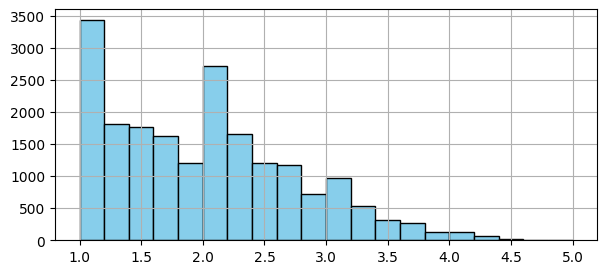

In [191]:
# Tracciare l'istogramma dei dati numerici di GameWeight
plt.figure(figsize=(7, 3))
df['GameWeight'].hist(bins=20, color='skyblue', edgecolor='black')
plt.show()


In [192]:
bins= [1, 2, 3, 5]
labels_weight = ['Easy', 'Medium', 'Hard']
df["WeightBin"] = pd.qcut(df["GameWeight"], 3, labels=["Easy", "Medium", "Hard"])

print(df['WeightBin'].value_counts())

WeightBin
Easy      6618
Hard      6575
Medium    6536
Name: count, dtype: int64


In [193]:
df["YearBin"], bins_tagliati = pd.qcut(df["YearPublished"], 4, labels=["Old", "Classic", "Modern", "New"], retbins=True)
print(df["YearBin"].value_counts())
print(f"I punti di taglio scelti sono: {bins_tagliati}")

YearBin
Old        5297
Classic    5289
Modern     5281
New        3862
Name: count, dtype: int64
I punti di taglio scelti sono: [1950. 2003. 2012. 2017. 2021.]


#uso solo MaxPlaytime e non MinPlaytime per evitare regole ridondanti e perché se un gioco ha maxtime alto è un gioco che dura tanto

In [194]:
# 0-30: Short, 30-60: Medium, 60-120: Long, 120+: VeryLong
bins_time = [0, 30, 60, 120, df['ComMaxPlaytime'].max()]
labels_time = ['Short(<30m)', 'Medium(30-60m)', 'Long(60-120m)', 'VeryLong(>120m)']

df['PlaytimeBin'] = pd.cut(df['ComMaxPlaytime'], bins=bins_time, labels=labels_time)

# Verifica la distribuzione dei nuovi bin
print(df['PlaytimeBin'].value_counts().sort_index())

PlaytimeBin
Short(<30m)        7919
Medium(30-60m)     6247
Long(60-120m)      3823
VeryLong(>120m)    1740
Name: count, dtype: int64


In [195]:
df["PopularityBin"] = pd.qcut(df["Avg_popularity_log"], 3, labels=["LowPop", "MedPop", "HighPop"])
print(df["PopularityBin"].value_counts())

PopularityBin
LowPop     6585
HighPop    6577
MedPop     6567
Name: count, dtype: int64


In [196]:
df["HasExpansions"] = df["NumExpansions_log"].apply(lambda x: "Exp:Yes" if x > 0 else "Exp:No")
print(df["HasExpansions"].value_counts())

HasExpansions
Exp:No     14522
Exp:Yes     5207
Name: count, dtype: int64


Binarizzo le variabili score

In [197]:
score_cols = [
    'Score_strategygames', 'Score_abstracts', 'Score_familygames', 
    'Score_thematic', 'Score_cgs', 'Score_wargames', 
    'Score_partygames', 'Score_childrensgames'
]

# Creiamo le versioni binarie (Es: Is_Strategy, Is_Wargame...)
for col in score_cols:
    new_name = 'Is_' + col.replace('Score_', '')
    df[new_name] = (df[col] > 0).astype(int)

# Vediamo quanti giochi ci sono per ogni sottodominio
print(df[[f'Is_{c.replace("Score_", "")}' for c in score_cols]].sum())

Is_strategygames     2264
Is_abstracts         1004
Is_familygames       2239
Is_thematic          1200
Is_cgs                299
Is_wargames          2825
Is_partygames         560
Is_childrensgames     813
dtype: int64


In [198]:
df['Rating']=df['Rating'].astype('category')

In [199]:
# Attenzione: Se imposti un min_support troppo alto (es. 0.05 o 5%), 
# l'algoritmo ignorerà completamente i CGS, i Party Games e probabilmente anche i Children's Games.

In [200]:
# Lista definitiva e aggiornata delle feature per il mining
features_finali = [
    'Rating',
    'MinPlayersBin', 
    'MaxPlayersBin', 
    'WeightBin', 
    'YearBin', 
    'PlaytimeBin',
    'PopularityBin',   
    'HasExpansions',
    'Is_strategygames', 'Is_abstracts', 'Is_familygames', 
    'Is_thematic', 'Is_cgs', 'Is_wargames', 
    'Is_partygames', 'Is_childrensgames'
]

# 3. Creazione della matrice finale
df_final_mining = pd.get_dummies(df[features_finali], prefix_sep=":")

print(f"\nNuovo numero di item totali: {df_final_mining.shape[1]}")

"""Il DataFrame one-hot encoded è stato convertito in una rappresentazione transaction-based selezionando, 
per ogni istanza, le feature attive (valore pari a 1), in modo da soddisfare i requisiti dell’algoritmo Apriori."""
transactions = df_final_mining.apply(
    lambda row: row[row == 1].index.tolist(),
    axis=1
).tolist()


Nuovo numero di item totali: 34


In [201]:
help(apriori)

Help on built-in function apriori in module fim:

apriori(...)
    apriori (tracts, target='s', supp=10, zmin=1, zmax=None, report='a',
             eval='x', agg='x', thresh=10, prune=None, algo='b', mode='',
             border=None)
    Find frequent item sets with the Apriori algorithm.
    tracts  transaction database to mine (mandatory)
            The database must be an iterable of transactions;
            each transaction must be an iterable of items;
            each item must be a hashable object.
            If the database is a dictionary, the transactions are
            the keys, the values their (integer) multiplicities.
    target  type of frequent item sets to find     (default: s)
            s/a   sets/all   all     frequent item sets
            c     closed     closed  frequent item sets
            m     maximal    maximal frequent item sets
            g     gens       generators
            r     rules      association rules
    supp    minimum support of an i

Closed itemset extraction

In [202]:
# supp = 2  # 2%
supp = 20  # 20%
zmin = 2  # minimum number of items per item set
report = "S" # (restituisce il supporto percentuale)

cl_itemsets = apriori(transactions, target="c", supp=supp, zmin=zmin, report="S")
print(f"Trovati {len(cl_itemsets)} itemset chiusi.")
print(pd.DataFrame(cl_itemsets, columns=["closed_itemset", "support"]))

Trovati 34 itemset chiusi.
                                                        closed_itemset    support
0                              (YearBin:Classic, HasExpansions:Exp:No)  20.502813
1                                     (YearBin:Old, MinPlayersBin:Duo)  20.715698
2                                  (YearBin:Old, HasExpansions:Exp:No)  23.427442
3                      (PlaytimeBin:Medium(30-60m), MinPlayersBin:Duo)  21.734503
4                   (PlaytimeBin:Medium(30-60m), HasExpansions:Exp:No)  22.256577
5                            (PopularityBin:LowPop, MinPlayersBin:Duo)  24.704749
6      (PopularityBin:LowPop, MinPlayersBin:Duo, HasExpansions:Exp:No)  22.266714
7                         (PopularityBin:LowPop, HasExpansions:Exp:No)  29.996452
8                                        (Rating:1, MinPlayersBin:Duo)  25.236961
9                  (Rating:1, MinPlayersBin:Duo, HasExpansions:Exp:No)  22.834406
10                                    (Rating:1, HasExpansions:Exp:No) 

Maximal itemsets

In [203]:
max_itemsets = apriori(transactions, target="m", supp=supp, zmin=zmin, report="S")
pd.DataFrame(max_itemsets, columns=["maximal_itemset", "support"])

,maximal_itemset,support
0,"(YearBin:Classic, HasExpansions:Exp:No)",20.502813
1,"(YearBin:Old, MinPlayersBin:Duo)",20.715698
2,"(YearBin:Old, HasExpansions:Exp:No)",23.427442
3,"(PlaytimeBin:Medium(30-60m), MinPlayersBin:Duo)",21.734503
4,"(PlaytimeBin:Medium(30-60m), HasExpansions:Exp:No)",22.256577
5,"(PopularityBin:LowPop, MinPlayersBin:Duo, HasExpansions:Exp:No)",22.266714
6,"(Rating:1, MinPlayersBin:Duo, HasExpansions:Exp:No)",22.834406
7,"(WeightBin:Easy, PlaytimeBin:Short(<30m), HasExpansions:Exp:No)",21.430382
8,"(WeightBin:Easy, MinPlayersBin:Duo, HasExpansions:Exp:No)",21.116123
9,"(PopularityBin:MedPop, MinPlayersBin:Duo)",22.925642


Support plots

Support vs number of itemsets

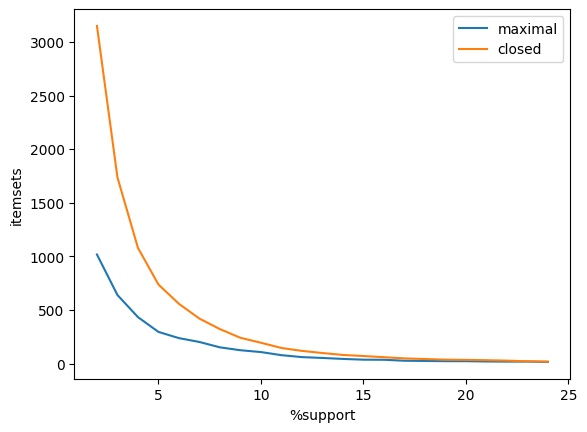

In [204]:
len_max_it = []
len_cl_it = []
max_supp = 25
for i in range(2, max_supp):
    max_itemsets = apriori(transactions, target="m", supp=i, zmin=zmin)
    cl_itemsets = apriori(transactions, target="c", supp=i, zmin=zmin)
    len_max_it.append(len(max_itemsets))
    len_cl_it.append(len(cl_itemsets))

plt.plot(np.arange(2, max_supp), len_max_it, label="maximal")
plt.plot(np.arange(2, max_supp), len_cl_it, label="closed")
plt.legend()
plt.xlabel("%support")
plt.ylabel("itemsets")

plt.show()

In [205]:
"""Dove si trova il "Segnale" nel rumore?
Sotto il 5% di supporto: C'è una quantità enorme di pattern (oltre 1000). 
Questo è "rumore": combinazioni troppo specifiche che riguardano pochi giochi.

Tra il 5% e il 10%: Le curve iniziano a flettere bruscamente. 
Questo è il tuo "sweet spot". Qui i pattern chiusi scendono sotto i 500 
e quelli massimali sotto i 200, permettendoti di trovare regole che sono sia frequenti che significative."""

'Dove si trova il "Segnale" nel rumore?\nSotto il 5% di supporto: C\'è una quantità enorme di pattern (oltre 1000). \nQuesto è "rumore": combinazioni troppo specifiche che riguardano pochi giochi.\n\nTra il 5% e il 10%: Le curve iniziano a flettere bruscamente. \nQuesto è il tuo "sweet spot". Qui i pattern chiusi scendono sotto i 500 \ne quelli massimali sotto i 200, permettendoti di trovare regole che sono sia frequenti che significative.'

Support vs number of itemset for HasExpansion -> Exp:Yes/Exp:No

In [206]:
# filter_1 = []
# filter_2 = []
# for i in range(2, max_supp):
#     max_itemsets = apriori(transactions, target="m", supp=i, zmin=zmin)
#     filter_1.append(len([item for item,supp in max_itemsets if any("Exp:Yes" in x for x in item)]))
#     filter_2.append(len([item for item,supp in max_itemsets if any("Exp:No" in x for x in item)]))

# plt.plot(np.arange(2, max_supp), filter_1, label="w/ Exp:Yes")
# plt.plot(np.arange(2, max_supp), filter_2, label="w/ Exp:No")
# plt.legend()
# plt.xticks()
# plt.xlabel("%support")
# plt.ylabel("itemsets")

# plt.show()

In [207]:
# filter_1 = []
# filter_2 = []
# # Definiamo il range di supporto (es. dal 2% al 25%)
# supports = np.arange(2, 26) 

# for s in supports:
#     # target="m" estrae solo i Maximal Itemsets (più veloce e sintetico)
#     max_itemsets = apriori(transactions, target="m", supp=s, zmin=2)
    
#     # Filtriamo contando quanti itemset contengono la versione "Yes" o "No"
#     # Usiamo 'in' per gestire eventuali prefissi tipo 'HasExpansions_Exp:Yes'
#     f1 = len([item for item, supp in max_itemsets if any("Exp:Yes" in x for x in item)])
#     f2 = len([item for item, supp in max_itemsets if any("Exp:No" in x for x in item)])
    
#     filter_1.append(f1)
#     filter_2.append(f2)

# # Grafico
# plt.figure(figsize=(10, 6))
# plt.plot(supports, filter_1, marker='o', label="Itemsets con Espansioni (Yes)")
# plt.plot(supports, filter_2, marker='s', label="Itemsets senza Espansioni (No)")

# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.xlabel("% Supporto Minimo")
# plt.ylabel("Numero di Maximal Itemsets")
# plt.title("Sensibilità dei Pattern rispetto al Supporto ed Espansioni")
# plt.show()

In [208]:
# # 1. Estraiamo i Maximal Itemsets a un supporto del 5%
# # Usiamo zmin=3 per cercare profili più ricchi (almeno 3 caratteristiche insieme)
# s = 5
# max_itemsets = apriori(transactions, target="m", supp=s, zmin=3)

# # 2. Filtriamo per trovare i pattern che descrivono i giochi con espansioni
# # Cerchiamo la stringa "Exp:Yes" all'interno degli itemset
# yes_patterns = [
#     {"Pattern": ", ".join(item), "Support %": round(supp, 2)} 
#     for item, supp in max_itemsets 
#     if any("Exp:Yes" in x for x in item)
# ]

# # 3. Creiamo un DataFrame per visualizzarli in modo ordinato
# df_yes_patterns = pd.DataFrame(yes_patterns).sort_values("Support %", ascending=False)

# print(f"--- Top Pattern Massimali per Giochi con Espansioni (Supporto > {s}%) ---")
# pd.set_option('display.max_colwidth', None)
# print(df_yes_patterns.head(10))

Rule extraction

In [209]:
# 1. Dopo aver convertito il DataFrame binario in una lista di transazioni
# Ogni riga diventa una lista di nomi di colonne (item) presenti


# 2. Lanciamo l'algoritmo FP-Growth
# target='r' genera regole di associazione
supp=5 # (supporto minimo 5%)
conf=72.5 # (confidenza minima 70%)
report='aScl' #include Confidenza e Lift nei risultati
rules = apriori(transactions, target='r', supp=supp, conf=conf, report=report)

# 3. Organizziamo i risultati in un DataFrame per una lettura facile
rules_df = pd.DataFrame(
    rules,
    columns=[
        "consequent",
        "antecedent",
        "abs_support",
        "%_support",
        "confidence",
        "lift",
    ],
)
rules_df.sort_values(by="lift", axis=0, ascending=False)

# Imposta pandas per non andare a capo e mostrare tutte le colonne
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None) # Evita che il testo nelle parentesi venga troncato
pd.set_option('display.width', 1000)        # Aumenta la larghezza totale della riga

print(f"Trovate {len(rules_df)} regole di associazione.")
rules_df

Trovate 599 regole di associazione.


,consequent,antecedent,abs_support,%_support,confidence,lift
0,PlaytimeBin:Short(<30m),"(Is_abstracts,)",747,3.786304,0.744024,1.853624
1,MinPlayersBin:Duo,"(Is_abstracts,)",885,4.485782,0.881474,1.275064
2,HasExpansions:Exp:No,"(Is_abstracts,)",885,4.485782,0.881474,1.197535
3,PopularityBin:HighPop,"(Is_thematic,)",934,4.734148,0.778333,2.334763
4,MinPlayersBin:Duo,"(PlaytimeBin:VeryLong(>120m), Is_wargames, WeightBin:Hard)",745,3.776167,0.750252,1.085249
...,...,...,...,...,...,...
594,HasExpansions:Exp:No,"(MaxPlayersBin:Mid Group,)",5999,30.407015,0.740617,1.006173
595,HasExpansions:Exp:No,"(Rating:2, MinPlayersBin:Duo)",4441,22.510011,0.735874,0.999729
596,HasExpansions:Exp:No,"(Rating:2,)",6462,32.753814,0.730500,0.992427
597,HasExpansions:Exp:No,"(MinPlayersBin:Duo,)",10306,52.237822,0.755627,1.026565


Tengo solo le regole che hanno Confidence(X → Y) > support(Y)

In [210]:
# Creiamo un dizionario supporti per tutti gli item singoli
item_support = {}
for item in df_final_mining.columns:
    item_support[item] = df_final_mining[item].mean()  # support % item singolo

# Funzione per ottenere supporto del consequent
def get_support_consequent(row):
    cons = row['consequent']
    # Se tuple → prendere max o media? Tipicamente prendiamo min singolo item
    if isinstance(cons, tuple):
        return max(item_support[i] for i in cons)
    else:
        return item_support[cons]

rules_df['support_consequent'] = rules_df.apply(get_support_consequent, axis=1)

rules_interesting = rules_df[
    rules_df['confidence'] > rules_df['support_consequent']
]
rules_interesting

,consequent,antecedent,abs_support,%_support,confidence,lift,support_consequent
0,PlaytimeBin:Short(<30m),"(Is_abstracts,)",747,3.786304,0.744024,1.853624,0.401389
1,MinPlayersBin:Duo,"(Is_abstracts,)",885,4.485782,0.881474,1.275064,0.691317
2,HasExpansions:Exp:No,"(Is_abstracts,)",885,4.485782,0.881474,1.197535,0.736074
3,PopularityBin:HighPop,"(Is_thematic,)",934,4.734148,0.778333,2.334763,0.333367
4,MinPlayersBin:Duo,"(PlaytimeBin:VeryLong(>120m), Is_wargames, WeightBin:Hard)",745,3.776167,0.750252,1.085249,0.691317
...,...,...,...,...,...,...,...
591,MinPlayersBin:Duo,"(PlaytimeBin:Short(<30m),)",5788,29.337523,0.730900,1.057257,0.691317
592,HasExpansions:Exp:No,"(PlaytimeBin:Short(<30m),)",6514,33.017386,0.822579,1.117522,0.736074
593,HasExpansions:Exp:No,"(MaxPlayersBin:Mid Group, MinPlayersBin:Duo)",3737,18.941659,0.756631,1.027928,0.736074
594,HasExpansions:Exp:No,"(MaxPlayersBin:Mid Group,)",5999,30.407015,0.740617,1.006173,0.736074


Filtro per lift e support 

In [211]:
# Filtro: Supporto > 5% e Lift > 1.5
s=5
l=1.5
rules_filtered = rules_df[(rules_df['%_support'] > s) & (rules_df['lift'] > l)].copy()
rules_filtered

,consequent,antecedent,abs_support,%_support,confidence,lift,support_consequent
7,WeightBin:Hard,"(PlaytimeBin:VeryLong(>120m), Is_wargames)",993,5.033200,0.934149,2.803014,0.333266
10,WeightBin:Hard,"(PlaytimeBin:VeryLong(>120m), MinPlayersBin:Duo)",1009,5.114299,0.889771,2.669853,0.333266
11,WeightBin:Hard,"(PlaytimeBin:VeryLong(>120m), HasExpansions:Exp:No)",1053,5.337321,0.865242,2.596254,0.333266
12,WeightBin:Hard,"(PlaytimeBin:VeryLong(>120m),)",1548,7.846318,0.889655,2.669507,0.333266
17,PopularityBin:HighPop,"(Is_familygames, Rating:2)",1008,5.109230,0.774789,2.324130,0.333367
...,...,...,...,...,...,...,...
517,PlaytimeBin:Short(<30m),"(WeightBin:Easy, Rating:2)",2021,10.243804,0.776114,1.933571,0.401389
520,PlaytimeBin:Short(<30m),"(WeightBin:Easy, MinPlayersBin:Duo, HasExpansions:Exp:No)",3135,15.890314,0.752520,1.874792,0.401389
522,PlaytimeBin:Short(<30m),"(WeightBin:Easy, MinPlayersBin:Duo)",3559,18.039434,0.752272,1.874173,0.401389
524,PlaytimeBin:Short(<30m),"(WeightBin:Easy, HasExpansions:Exp:No)",4228,21.430382,0.741234,1.846674,0.401389


Filtro per closed itemset e estraggo regole solo su di essi

In [212]:
closed_sets = [set(itemset) for itemset, _ in cl_itemsets]

def to_itemset(x):
    return {x} if isinstance(x, str) else set(x)

def from_closed(row):
    ant = to_itemset(row['antecedent'])
    cons = to_itemset(row['consequent'])
    return any((ant | cons).issubset(cs) for cs in closed_sets)

rules_closed = rules_df[rules_df.apply(from_closed, axis=1)]


In [213]:
print(f"{len(rules_closed)} regole estratte")
print(rules_closed)

17 regole estratte
                  consequent                                       antecedent  abs_support  %_support  confidence      lift  support_consequent
414        MinPlayersBin:Duo                          (PopularityBin:LowPop,)         4874  24.704749    0.740167  1.070662            0.691317
415     HasExpansions:Exp:No                          (PopularityBin:LowPop,)         5918  29.996452    0.898709  1.220950            0.736074
479        MinPlayersBin:Duo                                      (Rating:1,)         4979  25.236961    0.765529  1.107348            0.691317
480     HasExpansions:Exp:No                                      (Rating:1,)         5822  29.509859    0.895141  1.216103            0.736074
525  PlaytimeBin:Short(<30m)                                (WeightBin:Easy,)         4879  24.730093    0.737232  1.836702            0.401389
533     HasExpansions:Exp:No                                (WeightBin:Easy,)         5704  28.911754    0.861892  1.

Analisi per consequent

In [214]:
#estraggo i consequent più frequenti e analizzo alcune regole
rules_df['consequent'].value_counts()

consequent
HasExpansions:Exp:No       267
MinPlayersBin:Duo          199
PlaytimeBin:Short(<30m)     39
WeightBin:Hard              30
WeightBin:Easy              22
PopularityBin:HighPop       13
MaxPlayersBin:Mid Group      9
MaxPlayersBin:Solo/Duo       9
Rating:1                     6
Is_wargames                  4
Rating:3                     1
Name: count, dtype: int64

In [215]:
#Consequent==Rating:1 #basso
rules_df[rules_df['consequent']=='Rating:1']    

,consequent,antecedent,abs_support,%_support,confidence,lift,support_consequent
262,Rating:1,"(YearBin:Old, WeightBin:Easy, PlaytimeBin:Short(<30m), HasExpansions:Exp:No)",885,4.485782,0.803815,2.438263,0.329667
263,Rating:1,"(YearBin:Old, WeightBin:Easy, PlaytimeBin:Short(<30m))",917,4.647980,0.785775,2.383543,0.329667
266,Rating:1,"(YearBin:Old, WeightBin:Easy, MinPlayersBin:Duo, HasExpansions:Exp:No)",1077,5.458969,0.823394,2.497655,0.329667
268,Rating:1,"(YearBin:Old, WeightBin:Easy, MinPlayersBin:Duo)",1124,5.697197,0.806892,2.447596,0.329667
270,Rating:1,"(YearBin:Old, WeightBin:Easy, HasExpansions:Exp:No)",1337,6.776826,0.807367,2.449039,0.329667
271,Rating:1,"(YearBin:Old, WeightBin:Easy)",1402,7.106290,0.792090,2.402699,0.329667


In [216]:
#Consequent==Is_wargames
rules_df[rules_df['consequent']=='Is_wargames'].sort_values('lift', ascending=False)

,consequent,antecedent,abs_support,%_support,confidence,lift,support_consequent
62,Is_wargames,"(MaxPlayersBin:Solo/Duo, PopularityBin:MedPop, WeightBin:Hard)",798,4.044807,0.792453,5.534266,0.14319
78,Is_wargames,"(MaxPlayersBin:Solo/Duo, WeightBin:Hard, HasExpansions:Exp:No)",1153,5.844189,0.749675,5.235517,0.14319
5,Is_wargames,"(PlaytimeBin:VeryLong(>120m), WeightBin:Hard, MinPlayersBin:Duo)",745,3.776167,0.738355,5.156461,0.14319
72,Is_wargames,"(MaxPlayersBin:Solo/Duo, WeightBin:Hard, MinPlayersBin:Duo, HasExpansions:Exp:No)",863,4.374271,0.727043,5.077462,0.14319


In [217]:
#Consequent==WeightBin:Easy
rules_df[rules_df['consequent']=='WeightBin:Easy']

,consequent,antecedent,abs_support,%_support,confidence,lift,support_consequent
197,WeightBin:Easy,"(YearBin:Classic, Rating:1, PlaytimeBin:Short(<30m), MinPlayersBin:Duo)",750,3.801510,0.740375,2.207141,0.335445
199,WeightBin:Easy,"(YearBin:Classic, Rating:1, PlaytimeBin:Short(<30m), HasExpansions:Exp:No)",910,4.612499,0.762144,2.272037,0.335445
201,WeightBin:Easy,"(YearBin:Classic, Rating:1, PlaytimeBin:Short(<30m))",978,4.957170,0.751152,2.239269,0.335445
343,WeightBin:Easy,"(PopularityBin:LowPop, Rating:1, PlaytimeBin:Short(<30m), MinPlayersBin:Duo, HasExpansions:Exp:No)",1081,5.479244,0.765039,2.280667,0.335445
345,WeightBin:Easy,"(PopularityBin:LowPop, Rating:1, PlaytimeBin:Short(<30m), MinPlayersBin:Duo)",1114,5.646510,0.755254,2.251498,0.335445
347,WeightBin:Easy,"(PopularityBin:LowPop, Rating:1, PlaytimeBin:Short(<30m), HasExpansions:Exp:No)",1343,6.807238,0.756194,2.254298,0.335445
348,WeightBin:Easy,"(PopularityBin:LowPop, Rating:1, PlaytimeBin:Short(<30m))",1392,7.055603,0.747985,2.229827,0.335445
372,WeightBin:Easy,"(PopularityBin:LowPop, PlaytimeBin:Short(<30m), MaxPlayersBin:Mid Group, HasExpansions:Exp:No)",897,4.546607,0.729862,2.175799,0.335445
416,WeightBin:Easy,"(Rating:1, PopularityBin:MedPop, PlaytimeBin:Short(<30m), HasExpansions:Exp:No)",762,3.862335,0.731988,2.182140,0.335445
420,WeightBin:Easy,"(Rating:1, MaxPlayersBin:Small Group, PlaytimeBin:Short(<30m), MinPlayersBin:Duo, HasExpansions:Exp:No)",820,4.156318,0.779468,2.323681,0.335445


In [218]:
len_r = []
min_sup = 1
max_sup = 20
min_conf = 50
max_conf = 90
for i in range(min_sup, max_sup):  # support
    len_r_wrt_i = []
    for j in range(min_conf, max_conf):  # confidence
        rules = apriori(transactions, target="r", supp=i, zmin=zmin, conf=j, report="aScl")
        len_r_wrt_i.append(len(rules))  # study your characteristics/properties here

    len_r.append(len_r_wrt_i)
len_r = np.array(len_r)

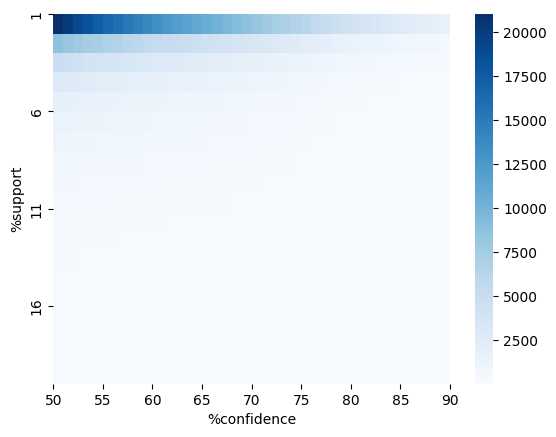

In [219]:
sns.heatmap(len_r, cmap="Blues", fmt='g')
plt.yticks(np.arange(0, max_sup-min_sup +1, 5), np.arange(min_sup, max_sup+1,5 ))
plt.xticks(np.arange(0, max_conf-min_conf+1, 5), np.arange(min_conf, max_conf+1, 5))
plt.xlabel("%confidence")
plt.ylabel("%support")
plt.show()